## Semantic vs. Sentiment: ROC Curve
This graph compares the Receiver Operating Characteristic (ROC) curves for semantic and sentiment analyses. The ROC curve is a graphical representation of the true positive rate against the false positive rate, illustrating the performance of each model in sockpuppet detection.

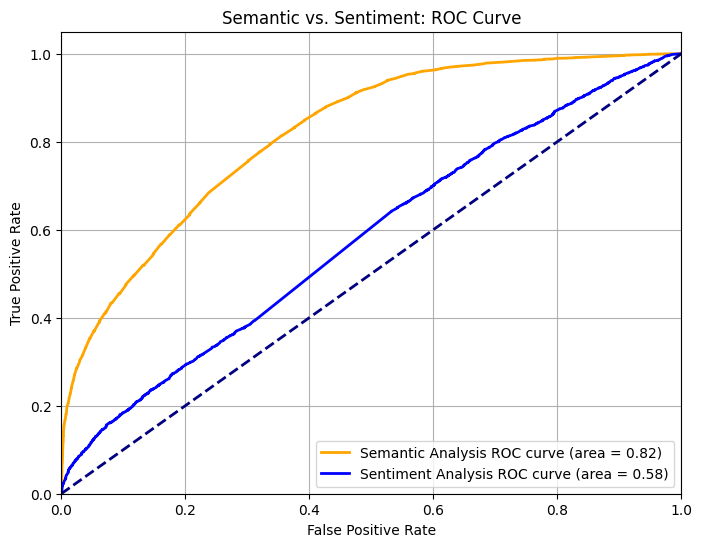

In [3]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc
from textblob import TextBlob

# Load the Wikipedia dataset
data = pd.read_csv('wikipedia_sockpuppet_dataset_CLEANED.csv')

# Preprocessing function
def preprocess(text):
    # Convert text to lowercase
    text = text.lower()
    return text

# Applying preprocessing to the edit text
data['processed_edit_text'] = data['edit_text'].apply(preprocess)

# Semantic Analysis using TF-IDF
tfidf = TfidfVectorizer(max_features=1000)
X_semantic = tfidf.fit_transform(data['processed_edit_text']).toarray()

# Sentiment Analysis
data['polarity'], data['subjectivity'] = zip(*data['edit_text'].apply(lambda text: (TextBlob(text).sentiment.polarity, TextBlob(text).sentiment.subjectivity)))
X_sentiment = data[['polarity', 'subjectivity']]

# Labels for the dataset
y = data['is_sockpuppet']

# Splitting the dataset for semantic analysis
X_train_semantic, X_test_semantic, y_train, y_test = train_test_split(X_semantic, y, test_size=0.2, stratify=y, random_state=42)

# Model Training using Random Forest for semantic analysis
model_semantic = RandomForestClassifier(n_estimators=100, random_state=42)
model_semantic.fit(X_train_semantic, y_train)

# Splitting the dataset for sentiment analysis
X_train_sentiment, X_test_sentiment, y_train_sentiment, y_test_sentiment = train_test_split(X_sentiment, y, test_size=0.2, stratify=y, random_state=42)

# Model Training using Random Forest for sentiment analysis
model_sentiment = RandomForestClassifier(n_estimators=100, random_state=42)
model_sentiment.fit(X_train_sentiment, y_train_sentiment)

# Get predicted probabilities for the test set for both models
y_proba_semantic = model_semantic.predict_proba(X_test_semantic)[:, 1]
y_proba_sentiment = model_sentiment.predict_proba(X_test_sentiment)[:, 1]

# Compute ROC curve and ROC area for both models
fpr_semantic, tpr_semantic, _ = roc_curve(y_test, y_proba_semantic)
roc_auc_semantic = auc(fpr_semantic, tpr_semantic)

fpr_sentiment, tpr_sentiment, _ = roc_curve(y_test, y_proba_sentiment)
roc_auc_sentiment = auc(fpr_sentiment, tpr_sentiment)

# Plot the overlaid ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_semantic, tpr_semantic, color='orange', lw=2, label='Semantic Analysis ROC curve (area = %0.2f)' % roc_auc_semantic)
plt.plot(fpr_sentiment, tpr_sentiment, color='blue', lw=2, label='Sentiment Analysis ROC curve (area = %0.2f)' % roc_auc_sentiment)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Semantic vs. Sentiment: ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Semantic vs. Sentiment: PR Curve
This visualization shows the Precision-Recall (PR) curves for semantic and sentiment analyses. The PR curve demonstrates the trade-off between precision and recall for each analysis type, providing insight into their effectiveness in identifying sockpuppets.

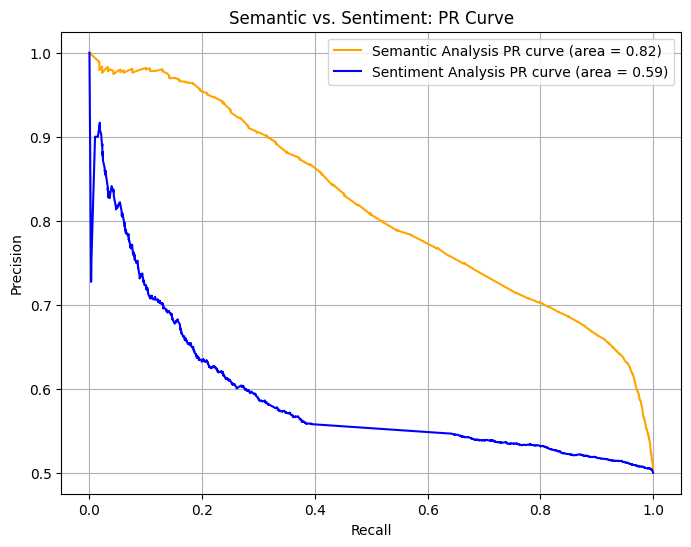

In [2]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, auc
from textblob import TextBlob
import matplotlib.pyplot as plt

# Load the training and testing datasets
train_data = pd.read_csv('wikipedia_sockpuppet_dataset_TRAIN.csv')
test_data = pd.read_csv('wikipedia_sockpuppet_dataset_TEST.csv')

# Preprocessing function
def preprocess(text):
    text = text.lower()
    return text

# Preprocess text data in both training and testing sets
train_data['processed_edit_text'] = train_data['edit_text'].apply(preprocess)
test_data['processed_edit_text'] = test_data['edit_text'].apply(preprocess)

# Semantic Analysis using TF-IDF
tfidf = TfidfVectorizer(max_features=1000)
X_train_semantic = tfidf.fit_transform(train_data['processed_edit_text']).toarray()
X_test_semantic = tfidf.transform(test_data['processed_edit_text']).toarray()

# Sentiment Analysis should be based on the preprocessed text
train_data['polarity'], train_data['subjectivity'] = zip(*train_data['processed_edit_text'].apply(lambda text: TextBlob(text).sentiment))
test_data['polarity'], test_data['subjectivity'] = zip(*test_data['processed_edit_text'].apply(lambda text: TextBlob(text).sentiment))

X_train_sentiment = np.array(train_data[['polarity', 'subjectivity']])
X_test_sentiment = np.array(test_data[['polarity', 'subjectivity']])

# Labels for the datasets
y_train = train_data['is_sockpuppet']
y_test = test_data['is_sockpuppet']

# Model Training using Random Forest for semantic analysis
model_semantic = RandomForestClassifier(n_estimators=100, random_state=42)
model_semantic.fit(X_train_semantic, y_train)

# Predictions for semantic analysis
y_score_semantic = model_semantic.predict_proba(X_test_semantic)[:, 1]

# Model Training using Random Forest for sentiment analysis
X_train_sentiment = train_data[['polarity', 'subjectivity']]
X_test_sentiment = test_data[['polarity', 'subjectivity']]
model_sentiment = RandomForestClassifier(n_estimators=100, random_state=42)
model_sentiment.fit(X_train_sentiment, y_train)

# Predictions for sentiment analysis
y_score_sentiment = model_sentiment.predict_proba(X_test_sentiment)[:, 1]

# Calculate Precision-Recall curve and AUC
precision_semantic, recall_semantic, _ = precision_recall_curve(y_test, y_score_semantic)
pr_auc_semantic = auc(recall_semantic, precision_semantic)
precision_sentiment, recall_sentiment, _ = precision_recall_curve(y_test, y_score_sentiment)
pr_auc_sentiment = auc(recall_sentiment, precision_sentiment)

# Plotting Precision-Recall curves
plt.figure(figsize=(8, 6))
plt.plot(recall_semantic, precision_semantic, color='orange', label='Semantic Analysis PR curve (area = %.2f)' % pr_auc_semantic)
plt.plot(recall_sentiment, precision_sentiment, color='blue', label='Sentiment Analysis PR curve (area = %.2f)' % pr_auc_sentiment)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Semantic vs. Sentiment: PR Curve')
plt.legend()
plt.grid(True)
plt.show()


## Combined Analysis: ROC Curve
The ROC curve compares the combined semantic and sentiment analysis with the individual semantic and sentiment analyses. It displays the true positive rate against the false positive rate, showcasing how the combined approach and each individual method perform in sockpuppet detection.

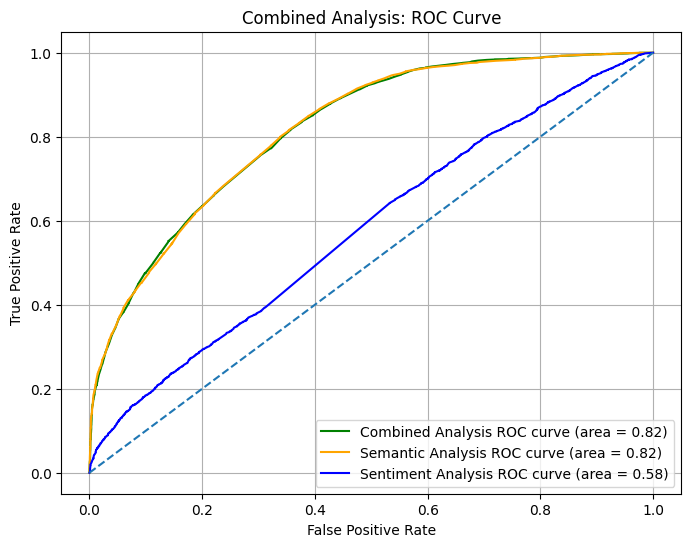

In [4]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Load the training and testing datasets
train_data = pd.read_csv('wikipedia_sockpuppet_dataset_TRAIN.csv')
test_data = pd.read_csv('wikipedia_sockpuppet_dataset_TEST.csv')

# Preprocess function
def preprocess(text):
    return text

# Apply preprocessing and feature extraction
tfidf = TfidfVectorizer(max_features=1000)
X_train_tfidf = tfidf.fit_transform(train_data['edit_text'].apply(preprocess))
X_test_tfidf = tfidf.transform(test_data['edit_text'].apply(preprocess))

# Sentiment features
train_data['polarity'] = train_data['edit_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
train_data['subjectivity'] = train_data['edit_text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
test_data['polarity'] = test_data['edit_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
test_data['subjectivity'] = test_data['edit_text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

# Combine features
X_train = np.hstack((X_train_tfidf.toarray(), train_data[['polarity', 'subjectivity']].values))
X_test = np.hstack((X_test_tfidf.toarray(), test_data[['polarity', 'subjectivity']].values))
y_train = train_data['is_sockpuppet']
y_test = test_data['is_sockpuppet']

# Train the models
model_combined = RandomForestClassifier(n_estimators=100, random_state=42)
model_combined.fit(X_train, y_train)
model_semantic = RandomForestClassifier(n_estimators=100, random_state=42)
model_semantic.fit(X_train[:, :-2], y_train)
model_sentiment = RandomForestClassifier(n_estimators=100, random_state=42)
model_sentiment.fit(X_train[:, -2:], y_train)

# Prediction and ROC curve computation
y_proba_combined = model_combined.predict_proba(X_test)[:, 1]
y_proba_semantic = model_semantic.predict_proba(X_test[:, :-2])[:, 1]
y_proba_sentiment = model_sentiment.predict_proba(X_test[:, -2:])[:, 1]

fpr_combined, tpr_combined, _ = roc_curve(y_test, y_proba_combined)
roc_auc_combined = auc(fpr_combined, tpr_combined)
fpr_semantic, tpr_semantic, _ = roc_curve(y_test, y_proba_semantic)
roc_auc_semantic = auc(fpr_semantic, tpr_semantic)
fpr_sentiment, tpr_sentiment, _ = roc_curve(y_test, y_proba_sentiment)
roc_auc_sentiment = auc(fpr_sentiment, tpr_sentiment)

# Plotting ROC Curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_combined, tpr_combined, color='green', label=f'Combined Analysis ROC curve (area = {roc_auc_combined:.2f})')
plt.plot(fpr_semantic, tpr_semantic, color='orange', label=f'Semantic Analysis ROC curve (area = {roc_auc_semantic:.2f})')
plt.plot(fpr_sentiment, tpr_sentiment, color='blue', label=f'Sentiment Analysis ROC curve (area = {roc_auc_sentiment:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Combined Analysis: ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

## Combined Analysis: PR Curve
This PR curve compares the combined semantic and sentiment analysis with the individual semantic and sentiment analyses. It evaluates the precision and recall for each method, showing the effectiveness and differences between combined and individual analyses in detecting sockpuppets.

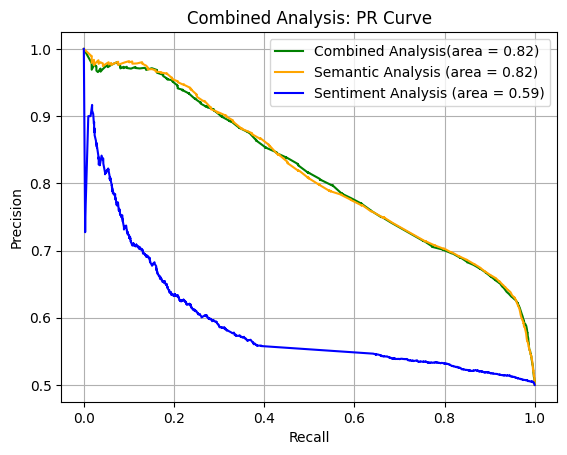

In [5]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Load the training and testing datasets
train_data = pd.read_csv('wikipedia_sockpuppet_dataset_TRAIN.csv')
test_data = pd.read_csv('wikipedia_sockpuppet_dataset_TEST.csv')

# Preprocess function
def preprocess(text):
    text = text.lower()
    return text

# Apply preprocessing and feature extraction
tfidf = TfidfVectorizer(max_features=1000)
X_train_tfidf = tfidf.fit_transform(train_data['edit_text'].apply(preprocess))
X_test_tfidf = tfidf.transform(test_data['edit_text'].apply(preprocess))

# Sentiment features
train_data['polarity'] = train_data['edit_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
train_data['subjectivity'] = train_data['edit_text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
test_data['polarity'] = test_data['edit_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
test_data['subjectivity'] = test_data['edit_text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

# Combine features
X_train = np.hstack((X_train_tfidf.toarray(), train_data[['polarity', 'subjectivity']].values))
X_test = np.hstack((X_test_tfidf.toarray(), test_data[['polarity', 'subjectivity']].values))
y_train = train_data['is_sockpuppet']
y_test = test_data['is_sockpuppet']

# Train the models
model_combined = RandomForestClassifier(n_estimators=100, random_state=42)
model_combined.fit(X_train, y_train)
model_semantic = RandomForestClassifier(n_estimators=100, random_state=42)
model_semantic.fit(X_train[:, :-2], y_train)
model_sentiment = RandomForestClassifier(n_estimators=100, random_state=42)
model_sentiment.fit(X_train[:, -2:], y_train)

# Prediction and PR curves
y_proba_combined = model_combined.predict_proba(X_test)[:, 1]
y_proba_semantic = model_semantic.predict_proba(X_test[:, :-2])[:, 1]
y_proba_sentiment = model_sentiment.predict_proba(X_test[:, -2:])[:, 1]

precision_combined, recall_combined, _ = precision_recall_curve(y_test, y_proba_combined)
precision_semantic, recall_semantic, _ = precision_recall_curve(y_test, y_proba_semantic)
precision_sentiment, recall_sentiment, _ = precision_recall_curve(y_test, y_proba_sentiment)

pr_auc_combined = auc(recall_combined, precision_combined)
pr_auc_semantic = auc(recall_semantic, precision_semantic)
pr_auc_sentiment = auc(recall_sentiment, precision_sentiment)

# Plotting
plt.figure()
plt.plot(recall_combined, precision_combined, color='green', label=f'Combined Analysis(area = {pr_auc_combined:.2f})')
plt.plot(recall_semantic, precision_semantic, color='orange', label=f'Semantic Analysis (area = {pr_auc_semantic:.2f})')
plt.plot(recall_sentiment, precision_sentiment, color='blue', label=f'Sentiment Analysis (area = {pr_auc_sentiment:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Combined Analysis: PR Curve')
plt.legend()
plt.grid(True)
plt.show()


## Combined Analysis: Confusion Matrix
The confusion matrix for the combined analysis of semantic and sentiment features is shown, detailing the number of true positives, true negatives, false positives, and false negatives, providing a comprehensive view of the model's classification accuracy.

              precision    recall  f1-score   support

           0       0.78      0.64      0.70      5382
           1       0.70      0.82      0.75      5382

    accuracy                           0.73     10764
   macro avg       0.74      0.73      0.73     10764
weighted avg       0.74      0.73      0.73     10764

Accuracy: 0.7301189149015236


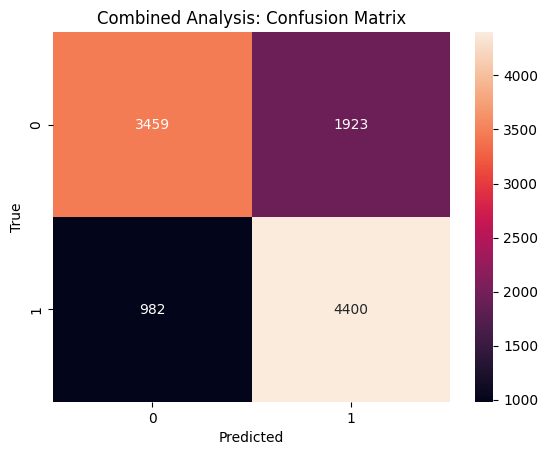

In [6]:
# Importing necessary tools and libraries
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the training and testing datasets
train_data = pd.read_csv('wikipedia_sockpuppet_dataset_TRAIN.csv')
test_data = pd.read_csv('wikipedia_sockpuppet_dataset_TEST.csv')

# Preprocess function
def preprocess(text):
    text = text.lower()
    return text

# Applying preprocessing and feature engineering
def prepare_features(data, tfidf_vectorizer=None):
    processed_text = data['edit_text'].apply(preprocess)
    if tfidf_vectorizer is None:
        tfidf_vectorizer = TfidfVectorizer(max_features=1000)
        tfidf_matrix = tfidf_vectorizer.fit_transform(processed_text)
    else:
        tfidf_matrix = tfidf_vectorizer.transform(processed_text)
    features = np.hstack((tfidf_matrix.toarray(),
                          data[['polarity', 'subjectivity']].values))
    return features, tfidf_vectorizer

train_data['polarity'] = train_data['edit_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
train_data['subjectivity'] = train_data['edit_text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
test_data['polarity'] = test_data['edit_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
test_data['subjectivity'] = test_data['edit_text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

X_train, tfidf_vectorizer = prepare_features(train_data)
X_test, _ = prepare_features(test_data, tfidf_vectorizer)

y_train = train_data['is_sockpuppet']
y_test = test_data['is_sockpuppet']

# Model training and evaluation
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# Generating and displaying Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Combined Analysis: Confusion Matrix')
plt.show()
